In [1]:
# Cell 1
# ==================================================
# 🧩 Cartoonizer Dataset - Kaggle Notebook Version
# ==================================================

# Install Hugging Face datasets library (quiet mode)
!pip install -q datasets pillow torchvision torch

# --------------------------------------------------
# Imports
# --------------------------------------------------
import torch
from torchvision import transforms
from datasets import load_dataset
from PIL import Image
from torch.utils.data import DataLoader, Subset

# Check device
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"✅ Running on device: {device}")

# --------------------------------------------------
# Transformation pipeline (256x256 + tensor + normalize)
# --------------------------------------------------
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])  # scale to [-1,1]
])

# --------------------------------------------------
# Custom Dataset Class (paired)
# --------------------------------------------------
class CartoonizerPairedDataset(torch.utils.data.Dataset):
    def __init__(self, split="train"):
        self.dataset = load_dataset("dqymaggie/cartoonizer-dataset", split=split)

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        entry = self.dataset[idx]

        photo = entry["original_image"].convert("RGB")
        cartoon = entry["cartoonized_image"].convert("RGB")

        photo = transform(photo)
        cartoon = transform(cartoon)

        return photo, cartoon

# --------------------------------------------------
# Load dataset
# --------------------------------------------------
paired_dataset = CartoonizerPairedDataset(split="train")

print(f"📦 Total dataset size: {len(paired_dataset)}")

# --------------------------------------------------
# FIXED SPLIT
# 4000 → Train
# 1000 → Test
# --------------------------------------------------
train_dataset = Subset(paired_dataset, range(0, 4000))
test_dataset  = Subset(paired_dataset, range(4000, 5000))

print(f"🟢 Train size: {len(train_dataset)}")
print(f"🔵 Test size: {len(test_dataset)}")

# --------------------------------------------------
# DataLoaders
# --------------------------------------------------
train_loader = DataLoader(
    train_dataset,
    batch_size=2,
    shuffle=True,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=2,
    shuffle=False,
    num_workers=2
)

# --------------------------------------------------
# Sanity Check
# --------------------------------------------------
photo_batch, cartoon_batch = next(iter(train_loader))

print("📸 Train photo batch shape:", photo_batch.shape)
print("🎨 Train cartoon batch shape:", cartoon_batch.shape)

# --------------------------------------------------
# Save sample image
# --------------------------------------------------
save_path = "/kaggle/working/sample_photo_cartoon.png"

photo = (photo_batch[0] * 0.5 + 0.5).permute(1, 2, 0)
cartoon = (cartoon_batch[0] * 0.5 + 0.5).permute(1, 2, 0)

combined = Image.new("RGB", (512, 256))
combined.paste(Image.fromarray((photo.numpy() * 255).astype("uint8")), (0, 0))
combined.paste(Image.fromarray((cartoon.numpy() * 255).astype("uint8")), (256, 0))

combined.save(save_path)

print(f"✅ Sample saved to: {save_path}")

✅ Running on device: cuda


README.md:   0%|          | 0.00/468 [00:00<?, ?B/s]

data/train-00000-of-00007-5f5144eeba7d0c(…):   0%|          | 0.00/475M [00:00<?, ?B/s]

data/train-00001-of-00007-71f5f057e68e92(…):   0%|          | 0.00/473M [00:00<?, ?B/s]

data/train-00002-of-00007-a3dca8537c5abd(…):   0%|          | 0.00/481M [00:00<?, ?B/s]

...

data/train-00004-of-00007-ce3c27b03f084d(…):   0%|          | 0.00/479M [00:00<?, ?B/s]

data/train-00005-of-00007-676034a5f1c6bd(…):   0%|          | 0.00/458M [00:00<?, ?B/s]

data/train-00006-of-00007-549000cd90e9d8(…):   0%|          | 0.00/458M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/5000 [00:00<?, ? examples/s]

📦 Total dataset size: 5000
🟢 Train size: 4000
🔵 Test size: 1000
📸 Train photo batch shape: torch.Size([2, 3, 256, 256])
🎨 Train cartoon batch shape: torch.Size([2, 3, 256, 256])
✅ Sample saved to: /kaggle/working/sample_photo_cartoon.png


In [2]:
# Cell 2
# ==================================================
# 🎯 CBAM (Convolutional Block Attention Module)
# Kaggle-ready version with test snippet
# ==================================================

import torch
import torch.nn as nn
import torch.nn.functional as F

# --------------------------------------------------
# Channel Attention
# --------------------------------------------------
class ChannelAttention(nn.Module):
    def __init__(self, in_channels, ratio=16):
        super(ChannelAttention, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)

        self.fc = nn.Sequential(
            nn.Conv2d(in_channels, in_channels // ratio, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels // ratio, in_channels, 1, bias=False)
        )

        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = self.fc(self.avg_pool(x))
        max_out = self.fc(self.max_pool(x))
        out = avg_out + max_out
        return self.sigmoid(out)


# --------------------------------------------------
# Spatial Attention
# --------------------------------------------------
class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super(SpatialAttention, self).__init__()
        padding = (kernel_size - 1) // 2
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=padding, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        x = torch.cat([avg_out, max_out], dim=1)
        x = self.conv(x)
        return self.sigmoid(x)


# --------------------------------------------------
# CBAM Module (Channel + Spatial Attention)
# --------------------------------------------------
class CBAM(nn.Module):
    def __init__(self, in_channels, ratio=16, kernel_size=7):
        super(CBAM, self).__init__()
        self.ca = ChannelAttention(in_channels, ratio)
        self.sa = SpatialAttention(kernel_size)

    def forward(self, x):
        out = x * self.ca(x)
        out = out * self.sa(out)
        return out


# --------------------------------------------------
# ✅ Quick Test (Kaggle GPU check)
# --------------------------------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Running CBAM test on: {device}")

# Dummy input (batch_size=8, channels=64, 128x128)
x = torch.randn(8, 64, 128, 128).to(device)

cbam = CBAM(in_channels=64).to(device)
y = cbam(x)

print("Input shape :", x.shape)
print("Output shape:", y.shape)
print("✅ CBAM module works correctly!")


Running CBAM test on: cuda
Input shape : torch.Size([8, 64, 128, 128])
Output shape: torch.Size([8, 64, 128, 128])
✅ CBAM module works correctly!


In [3]:
# Cell 3
# ==================================================
# 🧠 Dual-Branch Generator (Content + Style with CBAM)
# ==================================================

import torch
import torch.nn as nn

# --------------------------------------------------
# Basic ResNet Block
# --------------------------------------------------
class ResNetBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1, groups=channels, bias=False),
            nn.Conv2d(channels, channels, 1, bias=False),
            nn.InstanceNorm2d(channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(channels, channels, 3, padding=1, groups=channels, bias=False),
            nn.Conv2d(channels, channels, 1, bias=False),
            nn.InstanceNorm2d(channels)
        )

    def forward(self, x):
        return x + self.block(x)


# --------------------------------------------------
# ResNet Block + CBAM (for Style branch)
# --------------------------------------------------
class ResNetBlock_CBAM(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.res = ResNetBlock(channels)
        self.cbam = CBAM(channels)

    def forward(self, x):
        x = self.res(x)
        return self.cbam(x)


# --------------------------------------------------
# Dual Generator
# --------------------------------------------------
class DualGenerator(nn.Module):
    def __init__(self, in_channels=3, out_channels=3, ngf=64, n_blocks=3):
        super().__init__()

        # 🔹 Save architecture config (IMPORTANT)
        self.config = {
            "architecture": "DualGenerator",
            "in_channels": in_channels,
            "out_channels": out_channels,
            "ngf": ngf,
            "n_blocks": n_blocks,
            "fusion": "channel_concat_1x1",
            "style_attention": "CBAM"
        }

        # -------- Encoder --------
        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels, ngf, 7, padding=3),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ngf, ngf * 2, 4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ngf * 2, ngf * 4, 4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True)
        )

        channels = ngf * 4
        # -------- Shared ResNet --------
        self.shared_resnet = ResNetBlock(channels)

        # -------- Content Branch --------
        self.content_branch = nn.Sequential(
            *[ResNetBlock(channels) for _ in range(n_blocks - 1)]
        )

        # -------- Style Branch --------
        self.style_branch = nn.Sequential(
            *[ResNetBlock_CBAM(channels) for _ in range(n_blocks - 1)]
        )

        # -------- Learnable Fusion Weight --------
        # -------- Feature Fusion Layer --------
        self.fusion_conv = nn.Conv2d(channels * 2, channels, kernel_size=1)

        # -------- Decoder --------
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(channels, ngf * 2, 4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),

            nn.ConvTranspose2d(ngf * 2, ngf, 4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ngf, out_channels, 7, padding=3),
            nn.Tanh()
        )

    def forward(self, x):
        shared = self.encoder(x)
        shared = self.shared_resnet(shared)

        Fc = self.content_branch(shared)
        Fs = self.style_branch(shared)

        fused = torch.cat([Fc, Fs], dim=1)
        fused = self.fusion_conv(fused)

        return self.decoder(fused)
        

    def get_config(self):
        return self.config



# --------------------------------------------------
# ✅ Test
# --------------------------------------------------
if __name__ == "__main__":
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = DualGenerator().to(device)

    x = torch.randn(1, 3, 256, 256).to(device)
    y = model(x)

    print("Input :", x.shape)
    print("Output:", y.shape)
  #  print("α value:", model.alpha.item())


Input : torch.Size([1, 3, 256, 256])
Output: torch.Size([1, 3, 256, 256])


In [4]:
# Cell 4
# ==================================================
# 🧩 Multi-Branch PatchGAN Discriminator (Kaggle version)
# ==================================================

import torch
import torch.nn as nn
import torch.nn.functional as F

# ------------------------------------------------------
#   Single PatchGAN Block
# ------------------------------------------------------
class PatchGANBlock(nn.Module):
    def __init__(self, in_channels, ndf=64):
        super(PatchGANBlock, self).__init__()
        self.model = nn.Sequential(
            nn.Conv2d(in_channels, ndf, 4, 2, 1),  # 256 -> 128
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf, ndf * 2, 4, 2, 1),      # 128 -> 64
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1),  # 64 -> 32
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf * 4, 1, 4, 1, 1),        # Patch map
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)


# ------------------------------------------------------
#               Multi-Branch Discriminator
# ------------------------------------------------------
class MultiBranchDiscriminator(nn.Module):
    def __init__(self, in_channels=3, ndf=64):
        super(MultiBranchDiscriminator, self).__init__()

        # 🔹 Save architecture config (IMPORTANT)
        self.config = {
            "architecture": "MultiBranchPatchGAN",
            "in_channels": in_channels,
            "ndf": ndf,
            "branches": ["smooth", "edge", "texture"],
            "output": "patchgan"
        }

        # Shared PatchGAN module
        self.patchgan = PatchGANBlock(in_channels=in_channels, ndf=ndf)

    # ----- Preprocessing Functions -----
    def blur_image(self, x):
        return F.avg_pool2d(x, kernel_size=3, stride=1, padding=1)

    def edge_map(self, x):
        gray = x.mean(dim=1, keepdim=True)

        sobel_x = torch.tensor(
            [[1, 0, -1],
             [2, 0, -2],
             [1, 0, -1]],
            device=x.device
        ).float().view(1, 1, 3, 3)

        sobel_y = torch.tensor(
            [[1, 2, 1],
             [0, 0, 0],
             [-1, -2, -1]],
            device=x.device
        ).float().view(1, 1, 3, 3)

        edge_x = F.conv2d(gray, sobel_x, padding=1)
        edge_y = F.conv2d(gray, sobel_y, padding=1)
        edge = torch.sqrt(edge_x ** 2 + edge_y ** 2)

        return edge.repeat(1, 3, 1, 1)

    def color_shift(self, x):
        return x[:, [1, 2, 0], :, :]

    # ----- Forward Pass -----
    def forward(self, x):
        out_smooth = self.patchgan(self.blur_image(x))
        out_edge = self.patchgan(self.edge_map(x))
        out_texture = self.patchgan(self.color_shift(x))

        return out_smooth, out_edge, out_texture

    def get_config(self):
        return self.config


# ------------------------------------------------------
# ✅ Test
# ------------------------------------------------------
if __name__ == "__main__":
    device = "cuda" if torch.cuda.is_available() else "cpu"

    model = MultiBranchDiscriminator().to(device)
    dummy = torch.randn(1, 3, 256, 256).to(device)

    with torch.no_grad():
        s, e, t = model(dummy)

    print("Smooth:", s.shape)
    print("Edge  :", e.shape)
    print("Texture:", t.shape)
    print("✅ Discriminator OK")


Smooth: torch.Size([1, 1, 31, 31])
Edge  : torch.Size([1, 1, 31, 31])
Texture: torch.Size([1, 1, 31, 31])
✅ Discriminator OK


In [5]:
# Cell 5
# ================================================================
# 📦 Setup
# ================================================================
import torch
import torch.nn as nn
import torchvision.models as models

# Make sure device already exists from earlier cells
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ================================================================
# 🧠 VGG16-Based Perceptual (Content) Loss
# ================================================================
class VGG16_PerceptualLoss(nn.Module):
    def __init__(self, use_pretrained=True):
        super(VGG16_PerceptualLoss, self).__init__()
        try:
            if use_pretrained:
                vgg16 = models.vgg16(
                    weights=models.VGG16_Weights.IMAGENET1K_V1
                ).features
            else:
                vgg16 = models.vgg16(weights=None).features
        except Exception as e:
            print("⚠️ Could not load pretrained VGG16, using untrained weights:", e)
            vgg16 = models.vgg16(weights=None).features

        # Use first 16 layers (up to conv3_3)
        self.slice = nn.Sequential(*list(vgg16)[:16])

        # Freeze VGG
        for param in self.slice.parameters():
            param.requires_grad = False

    def forward(self, pred, target):
        # Inputs expected in [-1, 1]
        pred_norm = (pred + 1) / 2.0
        target_norm = (target + 1) / 2.0

        f_pred = self.slice(pred_norm)
        f_target = self.slice(target_norm)

        return nn.functional.l1_loss(f_pred, f_target)

# ================================================================
# ⚔️ Losses + Helpers
# ================================================================
criterion_adv = nn.BCELoss()
criterion_content = VGG16_PerceptualLoss().to(device)

def real_labels_like(pred):
    return torch.ones_like(pred)

def fake_labels_like(pred):
    return torch.zeros_like(pred)

# ================================================================
# ✅ OPTIONAL sanity test (SAFE)
# ================================================================
if __name__ == "__main__":
    pred = torch.randn(1, 3, 224, 224).to(device)
    target = torch.randn(1, 3, 224, 224).to(device)

    loss_val = criterion_content(pred, target)
    print(f"Perceptual Loss: {loss_val.item():.4f}")

    fake_output = torch.sigmoid(torch.randn(4, 1).to(device))
    adv_loss = criterion_adv(fake_output, real_labels_like(fake_output))
    print(f"Adversarial Loss: {adv_loss.item():.4f}")


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:03<00:00, 179MB/s]


Perceptual Loss: 0.4839
Adversarial Loss: 1.4364


In [6]:
# Cell 6
# ================================================================
# 🎨 Cartoon GAN Training — FULL CHECKPOINT VERSION (FINAL)
# ================================================================
import torch
import torch.nn as nn
import torch.optim as optim
import os

# ================================================================
# ⚙️ Device Setup
# ================================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Using device: {device}")

# ================================================================
# 🧩 Initialize Models
# ================================================================
generator = DualGenerator().to(device)
discriminator = MultiBranchDiscriminator().to(device)

# ================================================================
# 💡 Optimizers
# ================================================================
opt_G = optim.Adam(generator.parameters(), lr=2e-4, betas=(0.5, 0.999))
opt_D = optim.Adam(discriminator.parameters(), lr=2e-4, betas=(0.5, 0.999))

# ================================================================
# 📉 Loss Functions
# ================================================================
criterion_adv = nn.BCELoss()
criterion_content = VGG16_PerceptualLoss().to(device)
lambda_content = 10.0

# ================================================================
# 📁 Checkpoint directory
# ================================================================
os.makedirs("checkpoints", exist_ok=True)

# ================================================================
# 🔁 Training Loop
# ================================================================
num_epochs = 15   # adjust later when resuming

for epoch in range(num_epochs):
    generator.train()
    discriminator.train()

    for i, (photo, cartoon) in enumerate(train_loader):
        photo = photo.to(device)
        cartoon = cartoon.to(device)

        # ------------------------------------------------------------
        # 1️⃣ Train Discriminator
        # ------------------------------------------------------------
        opt_D.zero_grad()

        fake = generator(photo).detach()
        out_s_f, out_e_f, out_t_f = discriminator(fake)
        out_s_r, out_e_r, out_t_r = discriminator(cartoon)

        d_loss = (
            criterion_adv(out_s_r, real_labels_like(out_s_r)) +
            criterion_adv(out_s_f, fake_labels_like(out_s_f)) +
            criterion_adv(out_e_r, real_labels_like(out_e_r)) +
            criterion_adv(out_e_f, fake_labels_like(out_e_f)) +
            criterion_adv(out_t_r, real_labels_like(out_t_r)) +
            criterion_adv(out_t_f, fake_labels_like(out_t_f))
        ) / 6.0

        d_loss.backward()
        opt_D.step()

        # ------------------------------------------------------------
        # 2️⃣ Train Generator
        # ------------------------------------------------------------
        opt_G.zero_grad()

        fake = generator(photo)
        out_s_f, out_e_f, out_t_f = discriminator(fake)

        g_adv = (
            criterion_adv(out_s_f, real_labels_like(out_s_f)) +
            criterion_adv(out_e_f, real_labels_like(out_e_f)) +
            criterion_adv(out_t_f, real_labels_like(out_t_f))
        ) / 3.0

        content_loss = criterion_content(fake, cartoon)
        g_loss = g_adv + lambda_content * content_loss

        g_loss.backward()
        opt_G.step()

        if (i + 1) % 50 == 0:
            print(
                f"[Epoch {epoch+1}/{num_epochs}] "
                f"[Batch {i+1}/{len(train_loader)}] "
                f"D: {d_loss.item():.4f} | "
                f"G_adv: {g_adv.item():.4f} | "
                f"Content: {content_loss.item():.4f}"
            )

    # ------------------------------------------------------------
    # 💾 FULL CHECKPOINT (EXACT RESUME SAFE)
    # ------------------------------------------------------------
    checkpoint = {
        "epoch": epoch + 1,

        # Model states
        "generator_state": generator.state_dict(),
        "discriminator_state": discriminator.state_dict(),

        # Optimizer states (CRITICAL)
        "opt_G_state": opt_G.state_dict(),
        "opt_D_state": opt_D.state_dict(),

        # Architecture metadata
        "generator_config": generator.get_config(),
        "discriminator_config": discriminator.get_config(),

        # Training hyperparameters
        "lambda_content": lambda_content,
        "lr": opt_G.param_groups[0]["lr"],
        "betas": opt_G.param_groups[0]["betas"],
    }

    ckpt_path = f"checkpoints/checkpoint_epoch_{epoch+1}.pth"
    torch.save(checkpoint, ckpt_path)

    print(f"💾 Full checkpoint saved: {ckpt_path}\n")

# ================================================================
# 🏁 FINAL GENERATOR SAVE (INFERENCE ONLY)
# ================================================================
final_model_path = "dual_generator_final_inference.pth"

torch.save({
    "generator_state": generator.state_dict(),
    "generator_config": generator.get_config(),
 #   "alpha": generator.alpha.item(),
}, final_model_path)

print(f"✅ Final inference model saved: {final_model_path}")


✅ Using device: cuda
[Epoch 1/15] [Batch 50/2000] D: 0.6356 | G_adv: 1.0938 | Content: 0.5801
[Epoch 1/15] [Batch 100/2000] D: 0.4956 | G_adv: 1.0768 | Content: 0.5378
[Epoch 1/15] [Batch 150/2000] D: 0.6634 | G_adv: 0.7020 | Content: 0.4581
[Epoch 1/15] [Batch 200/2000] D: 0.6303 | G_adv: 0.7694 | Content: 0.3600
[Epoch 1/15] [Batch 250/2000] D: 0.6198 | G_adv: 0.8486 | Content: 0.5853
[Epoch 1/15] [Batch 300/2000] D: 0.6442 | G_adv: 0.8901 | Content: 0.5803
[Epoch 1/15] [Batch 350/2000] D: 0.6771 | G_adv: 0.8804 | Content: 0.4801
[Epoch 1/15] [Batch 400/2000] D: 0.7306 | G_adv: 0.8180 | Content: 0.3294
[Epoch 1/15] [Batch 450/2000] D: 0.6454 | G_adv: 0.8305 | Content: 0.5176
[Epoch 1/15] [Batch 500/2000] D: 0.7587 | G_adv: 0.9607 | Content: 0.4451
[Epoch 1/15] [Batch 550/2000] D: 0.6633 | G_adv: 0.7697 | Content: 0.3816
[Epoch 1/15] [Batch 600/2000] D: 0.6478 | G_adv: 0.8096 | Content: 0.5117
[Epoch 1/15] [Batch 650/2000] D: 0.6455 | G_adv: 0.6793 | Content: 0.4606
[Epoch 1/15] [Batc

In [7]:
# Cell 7
# ==================================================
# 🔍 Load Trained Dual Generator for Inference (FINAL)
# ==================================================
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load checkpoint
checkpoint = torch.load(
    "dual_generator_final_inference.pth",
    map_location=device
)

# Rebuild generator EXACTLY from saved config
cfg = checkpoint["generator_config"]

model = DualGenerator(
    in_channels=cfg["in_channels"],
    out_channels=cfg["out_channels"],
    ngf=cfg["ngf"],
    n_blocks=cfg["n_blocks"]
).to(device)

# Load weights
model.load_state_dict(checkpoint["generator_state"])
model.eval()

print("✅ Dual Generator loaded for inference")


✅ Dual Generator loaded for inference


/tmp/ipykernel_24/2024483604.py:48: UserWarning: Glyph 128444 (\N{FRAME WITH PICTURE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128444 (\N{FRAME WITH PICTURE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


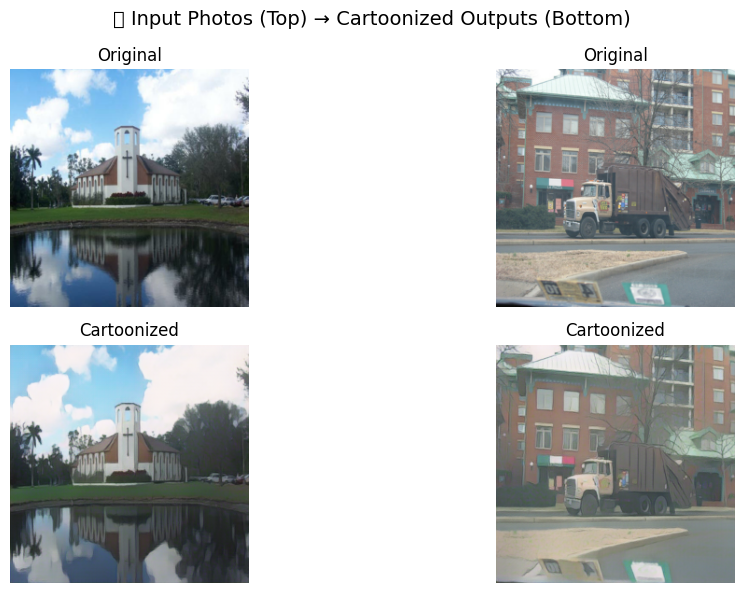

In [8]:
# Cell 8
import matplotlib.pyplot as plt

# --------------------------------------------------------
# 🧠 Switch LOADED Generator to Evaluation Mode
# --------------------------------------------------------
model.eval()
model = model.to(device)

# --------------------------------------------------------
# 🖼️ Get a batch of photos FROM TEST SET
# --------------------------------------------------------
photos, _ = next(iter(test_loader))   # ✅ use test_loader
photos = photos.to(device)

# --------------------------------------------------------
# 🎨 Generate Cartoonized Images
# --------------------------------------------------------
with torch.no_grad():
    fake_cartoons = model(photos)

# --------------------------------------------------------
# 📏 Normalize to [0, 1] range for visualization
# --------------------------------------------------------
photos_vis = (photos.cpu() + 1) / 2.0
fake_cartoons_vis = (fake_cartoons.cpu() + 1) / 2.0

# --------------------------------------------------------
# 🧩 Display
# --------------------------------------------------------
num_examples = min(4, photos_vis.size(0))
plt.figure(figsize=(12, 6))

for i in range(num_examples):
    # Original photo
    plt.subplot(2, num_examples, i + 1)
    plt.imshow(photos_vis[i].permute(1, 2, 0).clamp(0, 1))
    plt.title("Original")
    plt.axis("off")

    # Cartoonized image
    plt.subplot(2, num_examples, i + 1 + num_examples)
    plt.imshow(fake_cartoons_vis[i].permute(1, 2, 0).clamp(0, 1))
    plt.title("Cartoonized")
    plt.axis("off")

plt.suptitle("🖼️ Input Photos (Top) → Cartoonized Outputs (Bottom)", fontsize=14)
plt.tight_layout()
plt.show()

Found 3 images: ['/kaggle/input/datasets/gadhans/test-image/cat.jpg', '/kaggle/input/datasets/gadhans/test-image/girl.jpg', '/kaggle/input/datasets/gadhans/test-image/OIP.jpg']


/tmp/ipykernel_24/3151877474.py:78: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


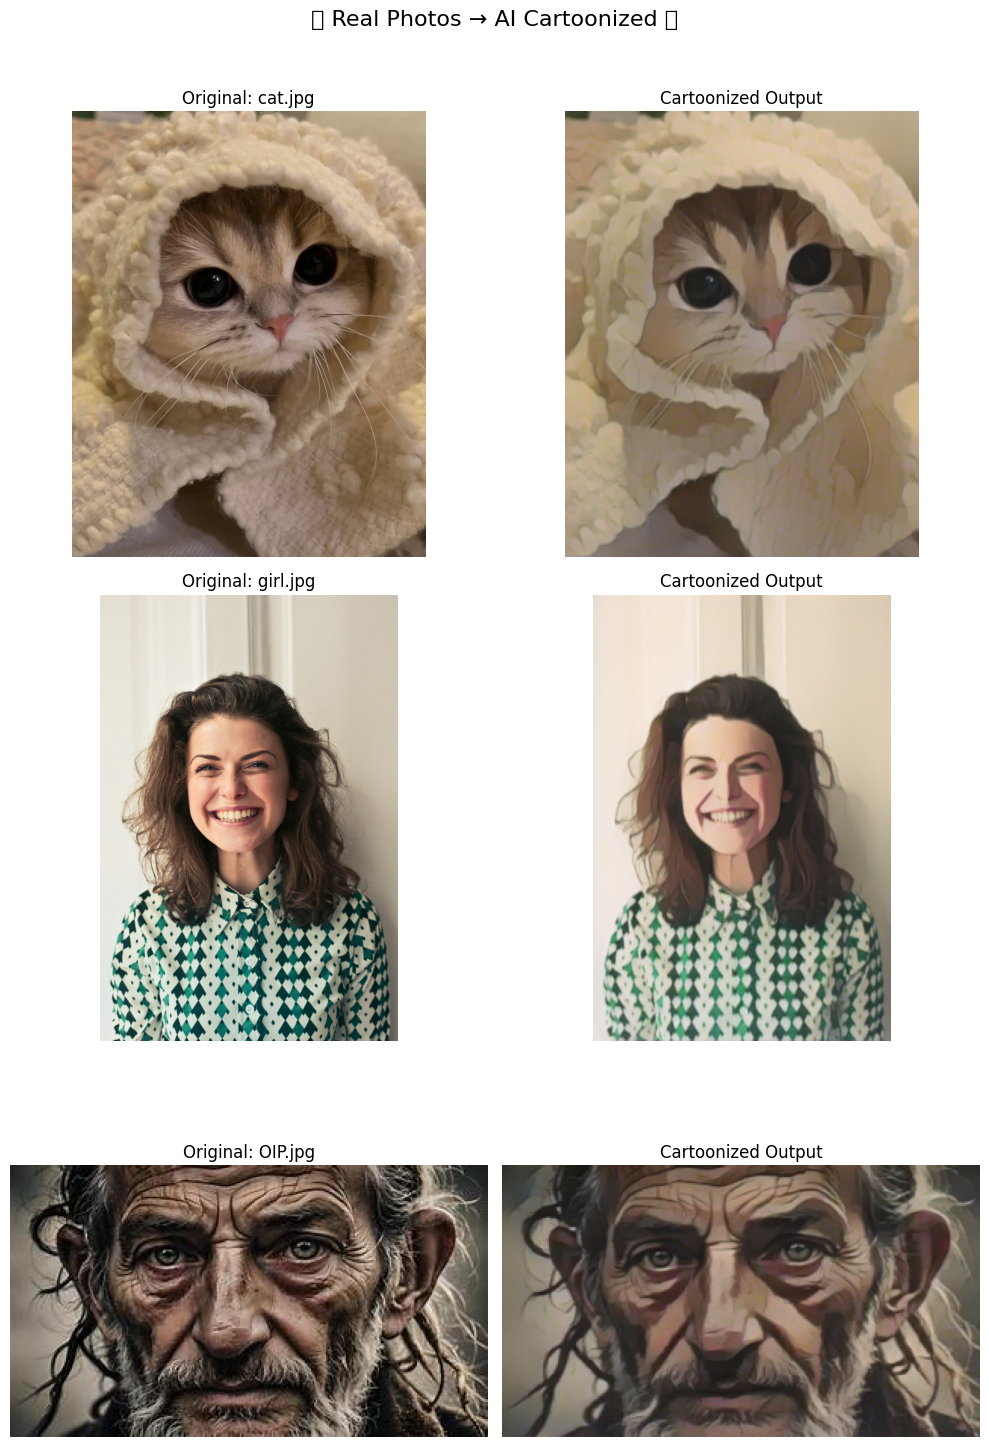

In [9]:
# Cell 9
from PIL import Image
import torchvision.transforms as T
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
import glob
import os

# ---------------------------------------------------
# 🧠 Device setup
# ---------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------------------------------------------------
# 🔄 Define Preprocessing Transform
# ---------------------------------------------------
transform = T.Compose([
    T.Resize((256, 256)),
    T.ToTensor(),
    T.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

# ---------------------------------------------------
# 📂 Get list of all images
# ---------------------------------------------------
dataset_path = "/kaggle/input/datasets/gadhans/test-image"

image_paths = glob.glob(f"{dataset_path}/*.jpg") + glob.glob(f"{dataset_path}/*.png")
num_images = len(image_paths)

print(f"Found {num_images} images: {image_paths}")

# ---------------------------------------------------
# 🖼️ Create figure
# ---------------------------------------------------
plt.figure(figsize=(10, num_images * 5))
plt.suptitle("✨ Real Photos → AI Cartoonized ✨", fontsize=16, y=1.02)

# ---------------------------------------------------
# 🔁 Loop and process each image
# ---------------------------------------------------
model.eval()
model = model.to(device)# ✅ use loaded inference model

for i, img_path in enumerate(image_paths):

    image = Image.open(img_path).convert("RGB")
    original_dims_hw = (image.height, image.width)

    input_tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_tensor)   # ✅ fixed

    output_resized = F.interpolate(
        output,
        size=original_dims_hw,
        mode="bilinear",
        align_corners=False
    )

    output_vis = (output_resized.squeeze(0).cpu() + 1) / 2.0
    output_vis = output_vis.permute(1, 2, 0).clamp(0, 1).numpy()

    # Original
    ax1 = plt.subplot(num_images, 2, i * 2 + 1)
    ax1.imshow(image)
    ax1.set_title(f"Original: {os.path.basename(img_path)}")
    ax1.axis("off")

    # Generated
    ax2 = plt.subplot(num_images, 2, i * 2 + 2)
    ax2.imshow(output_vis)
    ax2.set_title("Cartoonized Output")
    ax2.axis("off")

plt.tight_layout()
plt.show()

In [10]:
!pip install -q torch-fidelity


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.6/85.6 kB 3.0 MB/s eta 0:00:00


In [11]:
# Cell 10
from torch_fidelity import calculate_metrics
import os
from torchvision.utils import save_image

real_dir = "fid_real_photos"
fake_dir = "fid_fake_cartoons"

os.makedirs(real_dir, exist_ok=True)
os.makedirs(fake_dir, exist_ok=True)

model.eval()
model = model.to(device)# use loaded inference model

idx = 0
with torch.no_grad():
    for photos, cartoons in test_loader:   # ✅ use test set
        photos = photos.to(device)

        fake = model(photos)

        # Unnormalize to [0,1]
        photos_vis = (photos + 1) / 2.0
        fake_vis = (fake + 1) / 2.0

        for i in range(fake.size(0)):
            save_image(photos_vis[i], f"{real_dir}/{idx}.png")
            save_image(fake_vis[i], f"{fake_dir}/{idx}.png")
            idx += 1

        if idx >= 1000:
            break

metrics = calculate_metrics(
    input1=real_dir,
    input2=fake_dir,
    fid=True,
    isc=False,
    kid=False,
    cuda=torch.cuda.is_available()
)

print("FID score:", metrics["frechet_inception_distance"])

Creating feature extractor "inception-v3-compat" with features ['2048']
Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:00<00:00, 231MB/s]
Extracting statistics from input 1
Looking for samples non-recursivelty in "fid_real_photos" with extensions png,jpg,jpeg
Found 1000 samples
Processing samples
Extracting statistics from input 2
Looking for samples non-recursivelty in "fid_fake_cartoons" with extensions png,jpg,jpeg
Found 1000 samples
Processing samples


FID score: 38.30849047453745


Frechet Inception Distance: 38.30849


In [12]:
from skimage.metrics import structural_similarity as ssim
import numpy as np

def compute_ssim(model, dataloader, device):

    model.eval()
    model = model.to(device)
    ssim_scores = []

    with torch.no_grad():
        for photos, cartoons in dataloader:

            photos = photos.to(device)
            cartoons = cartoons.to(device)

            fake = model(photos)

            # Unnormalize to [0,1]
            fake = (fake + 1) / 2.0
            cartoons = (cartoons + 1) / 2.0

            fake = fake.cpu().numpy()
            cartoons = cartoons.cpu().numpy()

            for i in range(fake.shape[0]):

                s = ssim(
                    np.transpose(fake[i], (1, 2, 0)),
                    np.transpose(cartoons[i], (1, 2, 0)),
                    channel_axis=2,
                    data_range=1.0
                )

                ssim_scores.append(s)

    return sum(ssim_scores) / len(ssim_scores)


# Compute on TEST set
ssim_score = compute_ssim(model, test_loader, device)
print("SSIM (Fake vs Real Cartoons - Test Set):", ssim_score)

SSIM (Fake vs Real Cartoons - Test Set): 0.74257714


In [13]:
!pip install -q lpips


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 2.1 MB/s eta 0:00:00


In [14]:
# Cell 12
import lpips

lpips_fn = lpips.LPIPS(net='alex').to(device)
lpips_fn.eval()


def compute_lpips(model, dataloader, device):

    model.eval()
    model = model.to(device)
    scores = []

    with torch.no_grad():

        for photos, cartoons in dataloader:

            photos = photos.to(device)
            cartoons = cartoons.to(device)

            fake = model(photos)

            for i in range(fake.size(0)):

                score = lpips_fn(
                    fake[i:i+1].detach(),
                    cartoons[i:i+1].detach()
                )

                scores.append(score.item())

    return sum(scores) / len(scores)

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 193MB/s]


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth


In [15]:
lpips_score = compute_lpips(model, test_loader, device)

print(f"FID: {metrics['frechet_inception_distance']:.4f}")
print(f"SSIM: {ssim_score:.4f}")
print(f"LPIPS: {lpips_score:.4f}")

FID: 38.3085
SSIM: 0.7426
LPIPS: 0.0781
